In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
mj_df = pd.read_csv('/home/andrew/abm_violence/data/mother_jones.csv')

In [2]:
import re

def categorize_weapons(entry_text):
    categories = {
        'Handgun': False,
        'Semiautomatic Handgun': False,
        'Rifle': False,
        'Shotgun': False,
        'Semiautomatic Rifle': False,
        'Bladed Weapon': False,
        'Explosive': False,
        'Assault Weapon': False,
        'Accessory/Other': False
    }
    # Handle potential non-string inputs (like numpy.nan)
    if not isinstance(entry_text, str):
        return categories

    # 1. Normalize the text
    text = entry_text.lower().strip()
    text = text.replace('semiautiomatic', 'semiautomatic')
    text = text.replace('semi-automatic', 'semiautomatic')
    text = text.replace('semiauto ', 'semiautomatic ')

    # 2. Define search patterns for each category using regex word boundaries (\b)
    #    This ensures "rifle" doesn't match "trifler", for example.
    patterns = {
        # \b(a|b) matches "a" or "b" as whole words
        'Handgun': r'\b(handgun|pistol|revolver|derringer)',
        'Semiautomatic Handgun': r'\b(semiautomatic handgun|semiauto handgun|semi-automatic handgun|semiautomatic pistol|semiauto pistol|semi-automatic pistol)',
        'Shotgun': r'\b(shotgun)',
        'Semiautomatic Rifle': r'\b(semiautomatic rifle|semiauto rifle|semi-automatic rifle)', 
        'Bladed Weapon': r'\b(knife|knives)',
        'Assault Weapon': r'\b(assault)',
    }
    
    # 3. Check for matches
    for category, pattern in patterns.items():
        if re.search(pattern, text):
            categories[category] = True
    return categories

# Apply the categorization function to the 'weapon_details' column
weapon_categories = mj_df['weapon_type'].apply(categorize_weapons)
# Convert the resulting series of dictionaries into a DataFrame
weapon_categories_df = pd.DataFrame(weapon_categories.tolist())

def to_max_category(row):
    for category in [ 'Assault Weapon', 'Semiautomatic Rifle',  'Semiautomatic Handgun', 'Shotgun', 'Handgun', 'Rifle', 'Bladed Weapon']:
        if row[category]:
            return category
    return 'Unknown'

In [3]:
mj_df['max_weapon_category'] = weapon_categories_df.apply(to_max_category, axis=1)
# mj_df[['weapon_type', 'max_weapon_category']]

In [4]:
mj_df['max_weapon_category'].value_counts()

max_weapon_category
Semiautomatic Handgun    65
Semiautomatic Rifle      35
Assault Weapon           18
Handgun                  17
Shotgun                  13
Unknown                   3
Name: count, dtype: int64

In [42]:
import jax.numpy as jnp
import jax.random as jrand
from jax.scipy.signal import convolve2d

def sample_event_optstate(walk_radius, population_density, arm_density, atrisk_gathering_rate, mix_perc, rng_key):
    rng_key, subkey = jrand.split(rng_key)

    pgrid = (jrand.uniform(rng_key, (30, 30)) > 0.95).astype(jnp.float32)
    #Use jax to convolve population_grid with a 7x7 gaussian kernel to create pgrid
    kernel = jnp.arange(-4, 5)
    kernel = jnp.exp(-0.5 * (kernel / 2.5) ** 2)
    kernel = kernel / jnp.sum(kernel)
    kernel = jnp.outer(kernel, kernel)
    pgrid = convolve2d(pgrid, kernel, mode='same')
    pgrid = pgrid / jnp.max(pgrid)
    population_grid = pgrid * population_density

    flat_pop_grid = population_grid.flatten()
    probabilities = flat_pop_grid / jnp.sum(flat_pop_grid)

    rng_key, subkey = jrand.split(rng_key)

    # max_access = 150
    # access_count = jrand.poisson(subkey, lam=arm_density * population_grid.size)
    max_access = 1
    access_points = jrand.choice(subkey, population_grid.size, (max_access+1,), p=probabilities)

    # point_mask = jnp.arange(max_access+1) < access_count
    # access_grid = jnp.zeros(population_grid.shape, dtype=bool)
    # access_grid = access_grid.at[jnp.unravel_index(access_points, population_grid.shape)].set(point_mask)

    total_lambda = arm_density * population_grid.size
    access_grid = pgrid / pgrid.sum() * total_lambda
    access_grid = jrand.poisson(subkey, lam=access_grid)

    rng_key, subkey = jrand.split(rng_key)
    start_pos_r, start_pos_c = jnp.unravel_index(access_points[-1], population_grid.shape)
    random_walk = jrand.randint(subkey, (100, 2), -1, 2)
    random_walk = (jnp.cumsum(random_walk, axis=0) + jnp.array([start_pos_r, start_pos_c])) % population_grid.shape[0]
    walk_mask = jnp.arange(100) < walk_radius

    weapon_rolls = jnp.sum(access_grid[random_walk[:, 0], random_walk[:, 1]]*walk_mask)
    weapon_access = (weapon_rolls > 0)
    rng_key, subkey = jrand.split(rng_key)
    high_weapon_access = jrand.bernoulli(subkey, p=1 - jnp.exp(-0.1 * weapon_rolls)) #Assume each weapon has a 10% chance of being high powered

    population_encounters = jnp.sum(population_grid[random_walk[:, 0], random_walk[:, 1]]*walk_mask)

    rng_key, s1, s2 = jrand.split(rng_key, 3)
    location_count = jrand.poisson(s1, lam=population_encounters * atrisk_gathering_rate) + 1
    base_location_count = jrand.poisson(s2, lam=population_grid[start_pos_r, start_pos_c] * atrisk_gathering_rate) + 1

    rng_key, subkey = jrand.split(rng_key)
    max_location = 250
    location_mask = jnp.arange(max_location+5) < location_count
    loc_gathering_size = jrand.weibull_min(subkey, 2.4, 0.4, (max_location+5,))
    max_gathering_size = jnp.max(loc_gathering_size*location_mask, initial=0)


    base_gathering_size = loc_gathering_size[max_location]
    # base_gathering_size = loc_gathering_size[max_location:max_location+1]
    # base_sel_prob = base_gathering_size / jnp.sum(base_gathering_size)
    # base_gathering_size = jrand.choice(subkey, base_gathering_size, p=base_sel_prob)
    
    base_weapon_access = access_grid[start_pos_r, start_pos_c] > 0

    rng_key, subkey = jrand.split(rng_key)
    base_high_weapon_access = jrand.bernoulli(subkey, p=1 - jnp.exp(-0.1)) & base_weapon_access

    rng_key, subkey = jrand.split(rng_key)
    opt_state = jrand.bernoulli(subkey, p=mix_perc)

    gathering_size = jnp.where(opt_state, max_gathering_size, base_gathering_size)
    weapon_access = jnp.where(opt_state, weapon_access, base_weapon_access)
    high_weapon_access = jnp.where(opt_state, high_weapon_access, base_high_weapon_access)
    location_count = jnp.where(opt_state, location_count, base_location_count)

    # binomial_lambda = 12 + 80*high_weapon_access
    # rng_key, subkey = jrand.split(rng_key)
    # fatalities = jrand.binomial(subkey, n=location_count.astype(jnp.int32) + (location_count==0), p=binomial_lambda / (binomial_lambda + location_count), shape=())

    expon_lambda = 6 + 120 * high_weapon_access
    rng_key, subkey = jrand.split(rng_key)
    fatalities = jnp.remainder(jrand.exponential(subkey, shape=()) * expon_lambda, gathering_size)
    return (weapon_access & (location_count > 0)) * fatalities, opt_state, location_count, gathering_size, weapon_access, high_weapon_access, base_high_weapon_access

In [43]:
from gvabm.city_data import subsampled_city_data, subsample_weights
has_event = [len(c['events']) > 0 for c in subsampled_city_data]
event_city_params = [c['params'] for c in subsampled_city_data if len(c['events']) > 0]
print(event_city_params[4])

CityParams(population=24868.0, population_density=849.4, arm_count=105.0, arm_density=0.0535031847133758)


0.55289996 0.21779999
1.081 8.525771 3.514243e-09 521.46735
0.51669997 1.4287738
57 5529 125


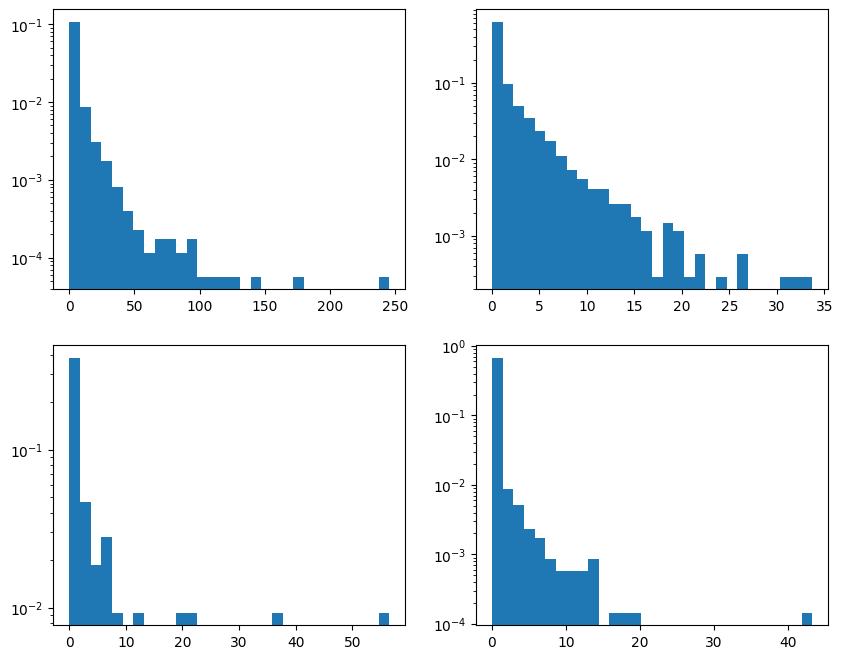

In [51]:
import jax.numpy as jnp
import jax.random as jrand
from jax.scipy.signal import convolve2d
import jax

# population_density = 1e5

# probabilities = convolve(probabilities, kernel.reshape((1, -1)), mode='same')
# plt.imshow(probabilities)
from gvabm.param_distr import MixedGeneralParams
params = MixedGeneralParams(propensity=6.024091e-08, walk_radius=52.101303, arm_bias=0.1, arm_weight=0.1, atrisk_gathering_rate=8.6441395e-06, mix_perc=0.5182773)
pop, population_density, arm_count, arm_density = event_city_params[4]
propensity, walk_radius, arm_bias, arm_weight, at_risk_gathering_rate, mix_perc = params
arm_density = arm_bias + arm_weight * arm_density
rng_key = jrand.PRNGKey(1)

# fatalities = sample_event(walk_radius, population_density, arm_density, at_risk_gathering_rate, mix_perc, rng_key)

batch_sample = jax.vmap(sample_event_optstate, in_axes=0, out_axes=0)
rng_keys = jrand.split(rng_key, num=10000)

def tile_param_tup(param_list, batch_size):
    return tuple(jnp.tile(param, (batch_size,)) for param in param_list)
walk_radius, population_density, arm_density, at_risk_gathering_rate, mix_perc = tile_param_tup(
    (walk_radius, population_density, arm_density, at_risk_gathering_rate, mix_perc), 10000
)
batch_output = batch_sample(
    walk_radius, population_density, arm_density, at_risk_gathering_rate, mix_perc, rng_keys
)
fatalities, state, location_count, gathering_size, weapon_access, high_weapon_access, base_high_weapon_access = batch_output
# fatalities = batch_output

print(weapon_access.mean(), high_weapon_access.mean())
print(location_count.mean(), gathering_size.mean(), gathering_size.min(), gathering_size.max())
print(state.mean(), fatalities.mean())
print(((~state) & (high_weapon_access)).sum(), weapon_access.sum(), base_high_weapon_access.sum())

high_weapon_access = high_weapon_access.astype(bool)
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0,0].hist(fatalities[state & high_weapon_access], bins=30, density=True); ax[0, 0].set_yscale('log')
ax[0,1].hist(fatalities[state & (~high_weapon_access)], bins=30, density=True); ax[0,1].set_yscale('log')
ax[1,0].hist(fatalities[(~state) & high_weapon_access], bins=30, density=True); ax[1,0].set_yscale('log')
ax[1,1].hist(fatalities[(~state) & (~high_weapon_access)], bins=30, density=True); ax[1,1].set_yscale('log')
plt.show()

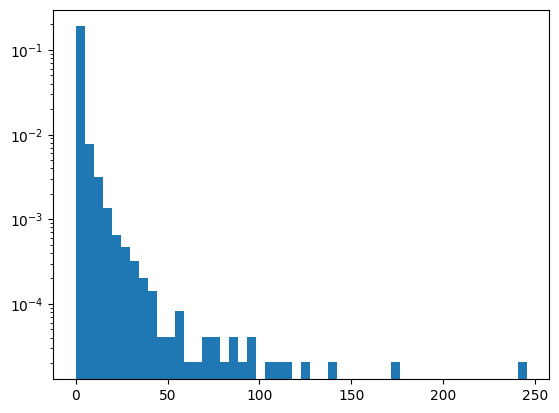

In [52]:
plt.hist(fatalities, bins=50, density=True)
plt.yscale('log')
plt.show()

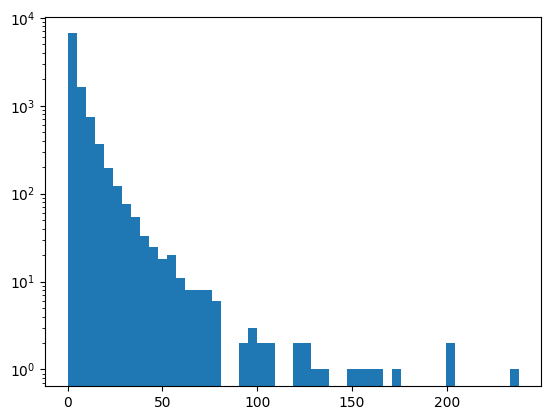

In [70]:
plt.hist(fatalities, bins=50)
plt.yscale('log')
plt.show()

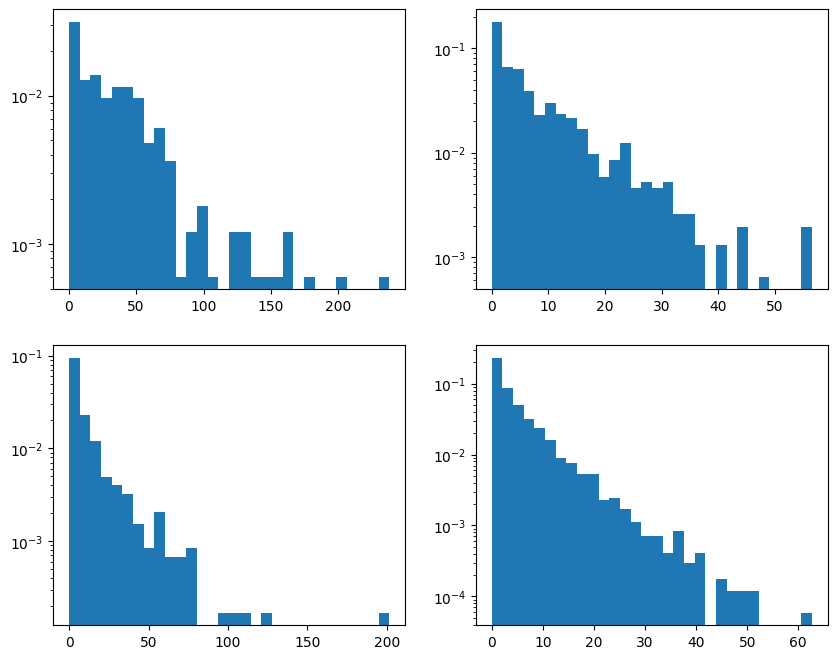

In [60]:
def sample_event(walk_radius, population_density, arm_density, atrisk_gathering_rate, mix_perc, rng_key):
    rng_key, subkey = jrand.split(rng_key)

    pgrid = (jrand.uniform(rng_key, (30, 30)) > 0.95).astype(jnp.float32)
    #Use jax to convolve population_grid with a 7x7 gaussian kernel to create pgrid
    kernel = jnp.arange(-4, 5)
    kernel = jnp.exp(-0.5 * (kernel / 2.5) ** 2)
    kernel = kernel / jnp.sum(kernel)
    kernel = jnp.outer(kernel, kernel)
    pgrid = convolve2d(pgrid, kernel, mode='same')
    pgrid = pgrid / jnp.max(pgrid)
    population_grid = pgrid * population_density

    flat_pop_grid = population_grid.flatten()
    probabilities = flat_pop_grid / jnp.sum(flat_pop_grid)

    rng_key, subkey = jrand.split(rng_key)

    max_access = 150
    access_count = jrand.poisson(subkey, lam=arm_density * population_grid.size)
    access_points = jrand.choice(subkey, population_grid.size, (max_access+1,), p=probabilities)

    point_mask = jnp.arange(max_access+1) < access_count
    access_grid = jnp.zeros(population_grid.shape, dtype=bool)
    access_grid = access_grid.at[jnp.unravel_index(access_points, population_grid.shape)].set(point_mask)

    rng_key, subkey = jrand.split(rng_key)
    start_pos_r, start_pos_c = jnp.unravel_index(access_points[-1], population_grid.shape)
    random_walk = jrand.randint(subkey, (100, 2), -1, 2)
    random_walk = (jnp.cumsum(random_walk, axis=0) + jnp.array([start_pos_r, start_pos_c])) % population_grid.shape[0]
    walk_mask = jnp.arange(100) < walk_radius

    weapon_rolls = jnp.sum(access_grid[random_walk[:, 0], random_walk[:, 1]]*walk_mask)
    weapon_access = (weapon_rolls > 0)
    rng_key, subkey = jrand.split(rng_key)
    high_weapon_access = jrand.bernoulli(subkey, p=1 - jnp.exp(-0.1 * weapon_rolls)) #Assume each weapon has a 10% chance of being high powered

    population_encounters = jnp.sum(population_grid[random_walk[:, 0], random_walk[:, 1]]*walk_mask)

    rng_key, s1, s2 = jrand.split(rng_key, 3)
    location_count = jrand.poisson(s1, lam=population_encounters * atrisk_gathering_rate) + 1
    base_location_count = jrand.poisson(s2, lam=population_grid[start_pos_r, start_pos_c] * atrisk_gathering_rate) + 1

    rng_key, subkey = jrand.split(rng_key)
    max_location = 250
    location_mask = jnp.arange(max_location+5) < location_count
    loc_gathering_size = jrand.weibull_min(subkey, 2, 0.4, (max_location+5,))
    max_gathering_size = jnp.max(loc_gathering_size*location_mask, initial=0)

    base_gathering_size = loc_gathering_size[max_location:max_location+5]
    base_sel_prob = base_gathering_size / jnp.sum(base_gathering_size)
    base_gathering_size = jrand.choice(subkey, base_gathering_size, p=base_sel_prob)

    base_weapon_access = access_grid[start_pos_r, start_pos_c]

    rng_key, subkey = jrand.split(rng_key)
    base_high_weapon_access = jrand.bernoulli(subkey, p=1 - jnp.exp(-0.1))

    rng_key, subkey = jrand.split(rng_key)
    opt_state = jrand.bernoulli(subkey, p=mix_perc)

    gathering_size = jnp.where(opt_state, max_gathering_size, base_gathering_size)
    weapon_access = jnp.where(opt_state, weapon_access, base_weapon_access)
    high_weapon_access = jnp.where(opt_state, high_weapon_access, base_high_weapon_access)
    location_count = jnp.where(opt_state, location_count, base_location_count)  

    # binomial_lambda = 12 + 80*high_weapon_access
    # rng_key, subkey = jrand.split(rng_key)
    # fatalities = jrand.binomial(subkey, n=location_count.astype(jnp.int32) + (location_count==0), p=binomial_lambda / (binomial_lambda + location_count), shape=())

    expon_lambda = 10 + 120 * high_weapon_access
    rng_key, subkey = jrand.split(rng_key)
    fatalities = jnp.remainder(jrand.exponential(subkey, shape=()) * expon_lambda, gathering_size)
    return (weapon_access & (location_count > 0)) * fatalities, opt_state, location_count, gathering_size, weapon_access, high_weapon_access, base_high_weapon_access

In [125]:
from gvabm.city_data import subsampled_city_data
city_params = [c['params'] for c in subsampled_city_data]
has_event = jnp.array([len(c['events']) > 0 for c in subsampled_city_data])
population_density = jnp.array([p.population_density for p in city_params])

In [131]:
population_density[~has_event].min()

Array(3.1, dtype=float32)

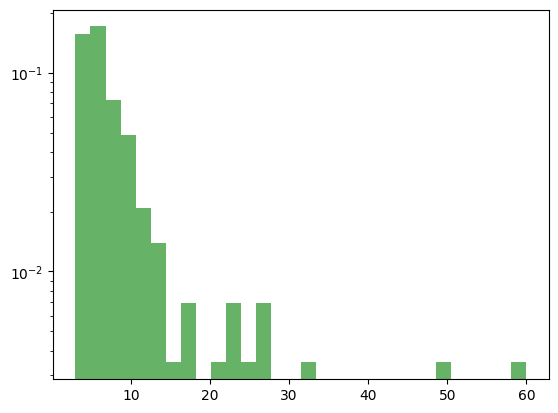

In [69]:
# mj_df['fatalities'].plot(kind='kde')
plt.hist(mj_df['fatalities'], bins=30, density=True, alpha=0.6, color='g')
plt.yscale('log')
plt.show()

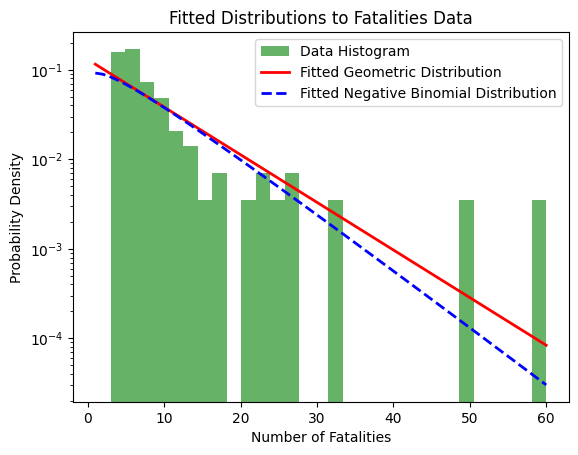

In [154]:
#fit scipy geometric and negative binomial distribution to the fatalities data
from scipy.stats import geom, expon
fatalities_data = mj_df['fatalities'].values
#fit geometric distribution
# Estimate the parameter p using the method of moments
mean_fatalities = np.mean(fatalities_data)
p_estimate = 1 / (mean_fatalities + 1)
# Create a geometric distribution with the estimated parameter
geom_dist = geom(p_estimate)

#fit negative binomial distribution
from scipy.stats import nbinom
# Estimate parameters r and p using method of moments
variance_fatalities = np.var(fatalities_data)
p_nbinom_estimate = mean_fatalities / variance_fatalities
r_nbinom_estimate = mean_fatalities * p_nbinom_estimate / (1 - p_nbinom_estimate)
# Create a negative binomial distribution with the estimated parameters
nbinom_dist = nbinom(r_nbinom_estimate, p_nbinom_estimate)

# Generate x values for plotting the fitted distribution
x = np.arange(1, max(fatalities_data) + 1)
# Get the probability mass function (PMF) values for the fitted distribution
pmf_values = geom_dist.pmf(x)
# Plot the histogram of the data
plt.hist(fatalities_data, bins=30, density=True, alpha=0.6, color='g', label='Data Histogram')
# Plot the fitted geometric distribution
plt.plot(x, pmf_values, 'r-', lw=2, label='Fitted Geometric Distribution')

pmf_values_nbinom = nbinom_dist.pmf(x)

plt.plot(x, pmf_values_nbinom, 'b--', lw=2, label='Fitted Negative Binomial Distribution')
plt.yscale('log')
plt.xlabel('Number of Fatalities')
plt.ylabel('Probability Density')
plt.title('Fitted Distributions to Fatalities Data')
plt.legend()
plt.show()

In [34]:
from scipy.stats import weibull_min, nbinom
weib_dist = weibull_min(0.4, scale=2)
# nbinom_dist = nbinom(3, p_nbinom_estimate)

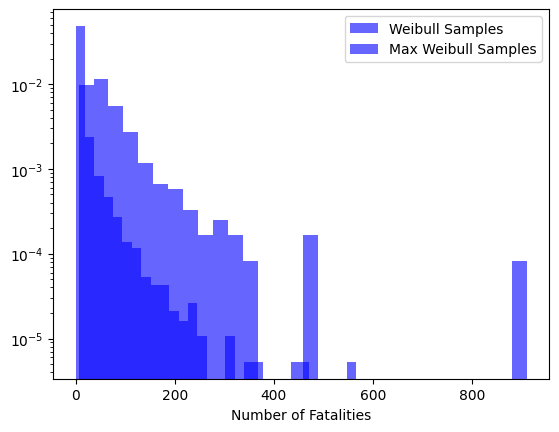

In [35]:
import matplotlib.pyplot as plt
import numpy as np
weibull_samples = weib_dist.rvs(size=(10000))
plt.hist(weibull_samples, bins=30, density=True, alpha=0.6, color='b', label='Weibull Samples')

weibull_samples = weib_dist.rvs(size=(10000)).reshape((-1, 25))
weibull_samples = np.max(weibull_samples, axis=1)
plt.hist(weibull_samples, bins=30, density=True, alpha=0.6, color='b', label='Max Weibull Samples')

plt.yscale('log')
plt.xlabel('Number of Fatalities')
plt.legend()
plt.show()

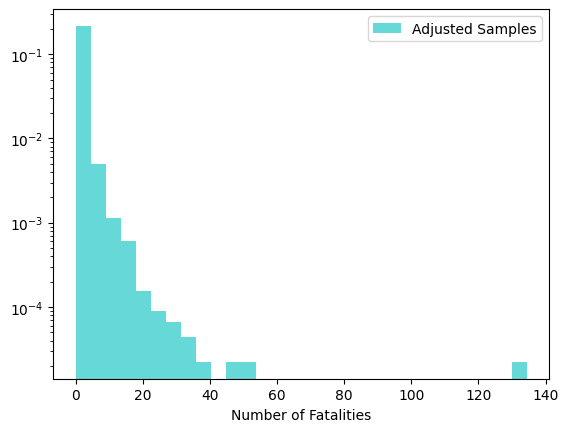

In [36]:
from scipy.stats import binom, weibull_min, truncnorm
binom_dist = binom(100, 0.1)
# truncnorm_dist = truncnorm(50, )

weib_dist = weibull_min(0.4, scale=2)
weibull_samples = weib_dist.rvs(size=10000)
binom_samples = binom_dist.rvs(size=10000) / 100
n_adj_samples = binom_samples * weibull_samples
plt.hist(n_adj_samples, bins=30, density=True, alpha=0.6, color='c', label='Adjusted Samples')
plt.yscale('log')
plt.xlabel('Number of Fatalities')
plt.legend()
plt.show()

In [17]:
import jax.random as jrand
import jax.numpy as jnp

weib_dist = weibull_min(0.4, scale=2)
weibull_samples = weib_dist.rvs(size=100000)

n = jnp.array(weibull_samples)
lamb = 20
p = lamb / (lamb + n)
key = jrand.PRNGKey(0)
fatalities = jrand.binomial(key, n=n, p=p)

weibull_samples = weib_dist.rvs(size=500000)
weibull_samples = weibull_samples.reshape((-1, 4)).max(axis=1)
lamb = 100
n = jnp.array(weibull_samples)
p = lamb / (lamb + n)
fatalities = jnp.concat([fatalities, jrand.binomial(key, n=n, p=p)])

# plt.hist(weibull_samples, bins=30, density=True, alpha=0.6, color='b', label='Weibull Samples')
# plt.show()

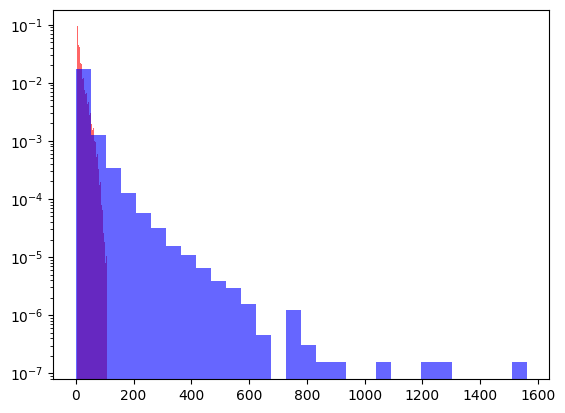

In [19]:
plt.hist(fatalities[fatalities >= 4], bins=30, density=True, alpha=0.6, color='r', label='JAX Fatalities Samples')
plt.hist(weibull_samples, bins=30, density=True, alpha=0.6, color='b', label='Weibull Samples')
# plt.hist(mj_df['fatalities'], bins=30, density=True, alpha=0.6, color='g', label='Data Histogram')
plt.yscale('log')
plt.show()

In [39]:
max(mj_df[mj_df['max_weapon_category'] == 'Handgun']['fatalities'])

12

Text(0.5, 0, 'Number of Fatalities')

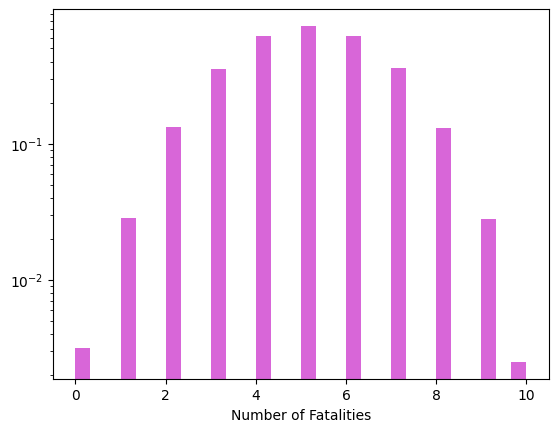

In [46]:
N = 10; l = 10
p = l / (l + N)
binom_dist = binom(N, p)
binom_samples = binom_dist.rvs(size=(100000))
plt.hist(binom_samples, bins=30, density=True, alpha=0.6, color='m', label='Binomial Samples')
plt.yscale('log')
plt.xlabel('Number of Fatalities')

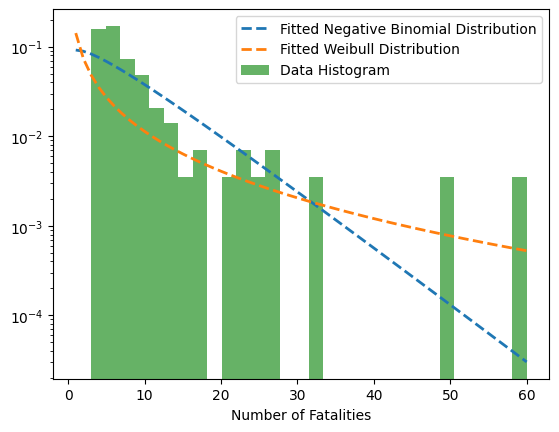

In [47]:
x = np.arange(1, max(fatalities_data) + 1)
pmf_values = nbinom_dist.pmf(x)
plt.plot(x, pmf_values, '--', lw=2, label='Fitted Negative Binomial Distribution')
pmf_values = weib_dist.pdf(x)
plt.plot(x, pmf_values, '--', lw=2, label='Fitted Weibull Distribution')
plt.hist(mj_df['fatalities'], bins=30, density=True, alpha=0.6, color='g', label='Data Histogram')
plt.yscale('log')
plt.xlabel('Number of Fatalities')
plt.legend()
plt.show()

In [10]:
import jax.random as jrand
key = jrand.PRNGKey(0)
#sample 1e4 fatalities from a negative binomial distribution with mean and variance matching the data
mean_fatalities = mj_df['fatalities'].mean()
var_fatalities = mj_df['fatalities'].var()
p = mean_fatalities / var_fatalities
r = mean_fatalities * p / (1 - p)
simulated_fatalities = jrand.negative_binomial(key, r, p, shape=(10000,))
plt.hist(simulated_fatalities, bins=30, density=True, alpha=0.6, color='b')
plt.yscale('log')
plt.show()

AttributeError: module 'jax.random' has no attribute 'negative_binomial'

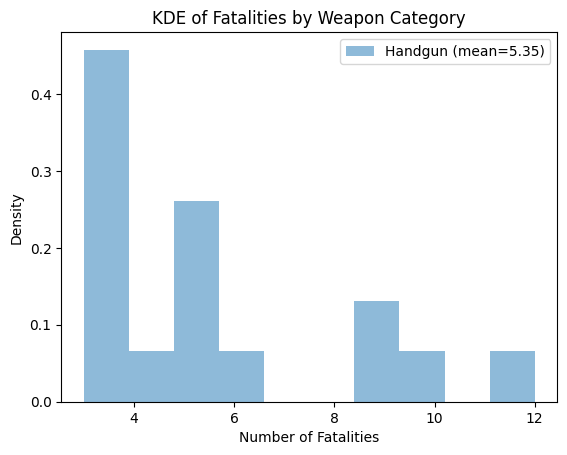

In [72]:
import matplotlib.pyplot as plt
total_weapons = weapon_categories_df.sum(axis=1)
# plt.hist(mj_df[mj_df['max_weapon_category'] == 'Semiautomatic Handgun']['fatalities'], bins=30, alpha=0.5, label='Assault Weapon')
#for each category, df in mj_df.groupby('max_weapon_category'), plot kernel density estimate of fatalities
for category, df in mj_df.groupby('max_weapon_category'):
    if category == 'Unknown' or category not in ['Handgun']:
        continue
    df['fatalities'].plot(kind='hist', label=category + f' (mean={df["fatalities"].mean():.2f})', alpha=0.5, density=True)

plt.xlabel('Number of Fatalities')
plt.ylabel('Density')
plt.title('KDE of Fatalities by Weapon Category')
plt.legend()
plt.show()

In [ ]:
#plot sub-statistics of the data grouped by weapon type
import matplotlib.pyplot as plt
weapon_groups = mj_df.groupby('weapon')
fig, ax = plt.subplots(len(weapon_groups), 1, figsize=(10, 5 * len(weapon_groups)))
for i, (weapon, group) in enumerate(weapon_groups):
    ax[i].bar(group['statistic_name'], group['statistic_value'])
    ax[i].set_title(f"Statistics for {weapon}")
    ax[i].set_xlabel('Statistic')
    ax[i].set_ylabel('Value')
fig.tight_layout()
fig.show()

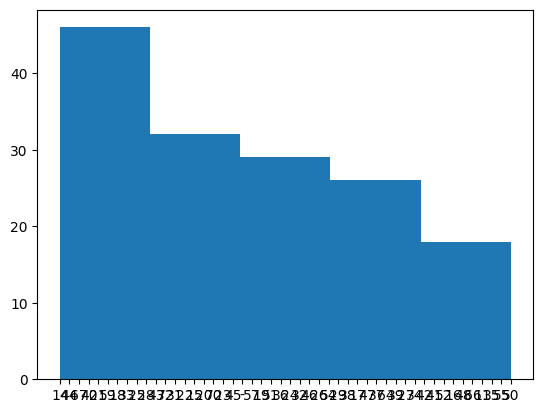

In [ ]:
import matplotlib.pyplot as plt
plt.hist(mj_df['age_of_shooter'], bins=10)
# plt.set_xticklabels(rotation=45)
#set label rotation to 45 degrees
plt.xticks(rotation=45)
plt.show()

In [13]:
mj_df[mj_df['fatalities'] > 15]

,case,location,date,summary,fatalities,injured,total_victims,location.1,age_of_shooter,prior_signs_mental_health_issues,...,weapon_details,race,gender,sources,mental_health_sources,sources_additional_age,latitude,longitude,type,year
3,Maine bowling alley and bar shootings,"Lewiston, Maine",10/25/23,"Robert Card, 40, an Army reservist and firearm...",18,13,31,Other,40,yes,...,AR-15-style rifle (Rugar SFAR),White,M,https://www.washingtonpost.com/nation/2023/10/...,https://www.nytimes.com/article/lewiston-maine...,-,-,-,Spree,2023
23,Robb Elementary School massacre,"Uvalde, Texas",5/24/22,"Salvador Ramos, 18, was identified by authorit...",21,17,38,School,18,yes,...,-,Latino,M,https://abcnews.go.com/US/texas-elementary-sch...,-,-,-,-,Mass,2022
38,El Paso Walmart mass shooting,"El Paso, Texas",8/3/19,"Patrick Crusius, 21, who was apprehended by po...",22,26,48,Workplace,21,-,...,"AK-47-style rifle, per authorities",White,M,https://www.washingtonpost.com/nation/2019/08/...,-,-,31.771068,-106.375655,Mass,2019
54,Marjory Stoneman Douglas High School shooting,"Parkland, Florida",2/14/18,"Nikolas J. Cruz, 19, heavily armed with an AR-...",17,17,34,School,19,Yes,...,AR-15,White,M,https://www.nytimes.com/2018/02/14/us/parkland...,https://www.nytimes.com/2018/02/15/us/nikolas-...,https://www.nytimes.com/2018/02/14/us/parkland...,26.30483,-80.269511,Mass,2018
57,Texas First Baptist Church massacre,"Sutherland Springs, Texas",11/5/17,"Devin Patrick Kelley, a 26-year-old ex-US Air ...",26,20,46,Religious,26,Yes,...,Ruger AR-556; Kelley also possessed semiautoma...,White,M,https://www.washingtonpost.com/news/morning-mi...,http://www.expressnews.com/news/local/article/...,https://www.washingtonpost.com/news/morning-mi...,29.273282,-98.056488,Mass,2017
60,Las Vegas Strip massacre,"Las Vegas, Nevada",10/1/17,"Stephen Craig Paddock, 64, fired a barrage of ...",60,546,606,Other,64,Yes,...,"AR-15-style and AK-47-style rifles and ""a larg...",White,M,https://www.lvmpd.com/en-us/Documents/1_Octobe...,https://www.nytimes.com/2017/10/13/us/stephen-...,https://www.lvmpd.com/en-us/Documents/1_Octobe...,36.095739,-115.171544,Mass,2017
70,Orlando nightclub massacre,"Orlando, Florida",6/12/2016,"Omar Mateen, 29, attacked the Pulse nighclub i...",49,53,102,Other,29,Unclear,...,"Sig Sauer MCX rifle, Glock 17 9mm; high-capaci...",Other,M,http://www.motherjones.com/politics/2016/06/as...,-,http://www.motherjones.com/politics/2016/06/as...,28.519718,-81.376777,Mass,2016
89,Sandy Hook Elementary massacre,"Newtown, Connecticut",12/14/2012,"Adam Lanza, 20, shot his mother dead at their ...",27,2,29,School,20,Yes,...,"10mm Glock, 9mm SIG Sauer P226 semiautomatic h...",white,Male,http://usnews.nbcnews.com/_news/2012/12/14/159...,http://usnews.nbcnews.com/_news/2012/12/14/159...,http://usnews.nbcnews.com/_news/2012/12/14/159...,41.4123225,-73.31142358,Mass,2012
109,Virginia Tech massacre,"Blacksburg, Virginia",4/16/2007,"Virginia Tech student Seung-Hui Cho, 23, opene...",32,23,55,School,23,Yes,...,"9mm Glock 19, .22-caliber Walther P22 semiauto...",Asian,Male,http://www.nytimes.com/2007/04/24/us/24virgini...,http://abcnews.go.com/US/story?id=3052278&page=1,http://www.nytimes.com/2007/04/24/us/24virgini...,37.2295733,-80.4139393,Mass,2007
141,Luby's massacre,"Killeen, Texas",10/16/1991,"George Hennard, 35, drove his pickup truck int...",24,20,44,Other,35,No,...,"9mm Glock 17, 9mm Ruger P89 semiautomatic hand...",white,Male,http://www.nytimes.com/1991/10/18/us/portrait-...,http://www.nytimes.com/1991/10/20/weekinreview...,http://www.nytimes.com/1991/10/18/us/portrait-...,31.1171194,-97.7277959,Mass,1991


In [15]:
mj_df[mj_df['location.1'] == 'School']

,case,location,date,summary,fatalities,injured,total_victims,location.1,age_of_shooter,prior_signs_mental_health_issues,...,weapon_details,race,gender,sources,mental_health_sources,sources_additional_age,latitude,longitude,type,year
0,Apalachee High School shooting,"Winder, Georgia",9/4/24,"Colt Gray, 14, was apprehended by responding p...",4,9,13,School,14,yes,...,AR-15,White,M,https://www.nbcnews.com/news/us-news/suspect-c...,https://www.washingtonpost.com/nation/2024/09/...,-,-,-,mass,2024
2,UNLV shooting,"Las Vegas, Nevada",12/6/23,"Anthony Polito, 67, a former university profes...",3,1,4,School,67,-,...,-,White,M,https://www.nbcnews.com/news/us-news/anthony-p...,-,-,-,-,mass,2023
10,Nashville Christian school shooting,"Nashville, Tennessee",3/27/23,"Audrey Hale, 28, who was a former student at t...",6,6,12,School,28,-,...,-,White,"F (""identifies as transgender"" and ""Audrey Hal...",https://www.tennessean.com/story/news/crime/20...,-,-,-,-,Mass,2023
11,Michigan State University shooting,"East Lansing, Michigan",2/13/23,"Anthony D. McRae, 43, opened fire at Berkey Ha...",3,5,8,School,43,-,...,-,Black,M,https://www.cnn.com/us/live-news/michigan-stat...,-,-,-,-,Mass,2023
16,University of Virginia shooting,"Charlottesville, Virginia",11/13/22,"Christopher Darnell Jones Jr., 22, allegedly o...",3,2,5,School,22,-,...,Glock 45 9mm; Ruger AR-556 rifle (in his dorm ...,Black,M,https://dailyprogress.com/news/local/guns-and-...,-,-,-,-,Mass,2022
23,Robb Elementary School massacre,"Uvalde, Texas",5/24/22,"Salvador Ramos, 18, was identified by authorit...",21,17,38,School,18,yes,...,-,Latino,M,https://abcnews.go.com/US/texas-elementary-sch...,-,-,-,-,Mass,2022
26,Oxford High School shooting,"Oxford, Michigan",11/30/21,"Ethan Crumbley, a 15-year-old student at Oxfor...",4,7,11,School,15,-,...,Sig Sauer 9mm pistol,-,M,https://www.washingtonpost.com/nation/2021/11/...,-,-,42.84410784,-83.25992831,Mass,2021
51,Santa Fe High School shooting,"Santa Fe, Texas",5/18/18,"Dimitrios Pagourtzis, a 17-year-old student, o...",10,13,23,School,17,-,...,-,White,M,https://www.chron.com/news/houston-texas/artic...,-,https://www.chron.com/news/houston-texas/artic...,29.392825,-95.141972,Mass,2018
54,Marjory Stoneman Douglas High School shooting,"Parkland, Florida",2/14/18,"Nikolas J. Cruz, 19, heavily armed with an AR-...",17,17,34,School,19,Yes,...,AR-15,White,M,https://www.nytimes.com/2018/02/14/us/parkland...,https://www.nytimes.com/2018/02/15/us/nikolas-...,https://www.nytimes.com/2018/02/14/us/parkland...,26.30483,-80.269511,Mass,2018
76,Umpqua Community College shooting,"Roseburg, Oregon",10/1/2015,26-year-old Chris Harper Mercer opened fire at...,9,9,18,School,26,Unclear,...,"9 mm Glock pistol, .40 caliber Smith & Wesson,...",Other,Male,http://www.nytimes.com/2015/10/03/us/chris-har...,http://www.latimes.com/nation/nationnow/la-na-...,http://www.nytimes.com/2015/10/03/us/chris-har...,43.289538,-123.333193,Mass,2015
